# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

Alumno: Martin Gabriel Quiroga

Legajo: a2412

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

#### Resolución
Dado que es un problema de clasificación binario, se considera que, para observar la distribución de los datos y cómo impactan en el target, resulta muy útil hacer un histograma de todas las variables categóricas (`workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `skill-profile`, `native-country`), distinguiendo la proporción del target en las barras. 

Para las variables numéricas (`age`, `capital-gain`, `capital-loss`, `hours-per-week`), al revisar un poco el dataset se observan algunas particularidades que no permitirían un análisis tan estandarizado. Esto es porque en todas los atributos numéricos, excepto `age`, la mayoría de los datos se agrupan en un solo valor específico.
- `age`: Es el único con una distribución "pareja" en general, es útil revisarlo en un KDE o en un histograma.
- `capital-gain`: La mayoría de los registros tienen esta columna en 0. Quizás sea útil hacer un gráfico ignorando estos valores para ver la distribución de los demás.
- `capital-loss`: Similar a capital-gain.
- `hours-per-week`: la mayoría está en 40 horas, sin embargo existe una varianza más interesante. Se puede usar un kde o un histograma.

Se agrega al inicio también una visualización de la proporción del dataset. Es importante conocerla para distinguir si la distribución del target en los distintos features y categorías muestra alguna correlación con el feature en sí o solo siguen la distribución del dataset.

Se incluye también un analisis de valores nulos, outliers (numéricas) y cardinalidad (categóricas).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_tr = pd.read_csv('data/adult_train.csv')
df_val = pd.read_csv('data/adult_val.csv')
df = pd.concat([df_tr, df_val], axis=0, ignore_index=True)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45222 non-null  int64
 1   workclass       45222 non-null  str  
 2   education       45222 non-null  str  
 3   marital-status  45222 non-null  str  
 4   occupation      45222 non-null  str  
 5   relationship    45222 non-null  str  
 6   race            45222 non-null  str  
 7   sex             45222 non-null  str  
 8   capital-gain    45222 non-null  int64
 9   capital-loss    45222 non-null  int64
 10  hours-per-week  45222 non-null  int64
 11  skill-profile   45222 non-null  str  
 12  native-country  45222 non-null  str  
 13  income          45222 non-null  str  
dtypes: int64(4), str(10)
memory usage: 4.8 MB
None


In [3]:
cat_features = df[["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "skill-profile", "native-country"]]
num_features = df[["age", "capital-gain", "capital-loss", "hours-per-week"]]
target = df["income"]

([<matplotlib.patches.Wedge at 0x1df76c28770>,
 [Text(-0.7830681052426975, 0.772531127237998, '<=50K'),
  Text(0.7830679885937336, -0.7725312454779835, '>50K')],
 [Text(-0.4271280574051077, 0.4213806148570898, '75.2%'),
  Text(0.4271279937784001, -0.4213806793516273, '24.8%')])

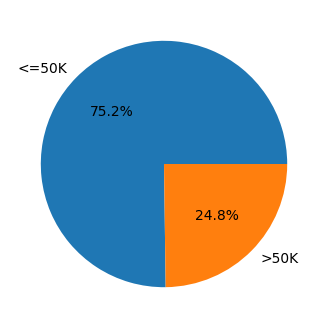

In [4]:
# Primero se verifica la proporción del target
plt.figure(figsize=(6, 4))
plt.pie(df["income"].value_counts(), labels=df["income"].value_counts().index, autopct='%1.1f%%')

Variables categóricas

In [5]:
def plot_categorical_feature(df, feature, y_top_limit=None):
    plt.figure(figsize=(12,5))
    sns.countplot(data=df, x=feature, hue="income")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.ylim(0, y_top_limit)  # Limitar el eje y si se indica un límite
    plt.title(f"Distribución de {feature} por ingreso (<=50K vs >50K)")
    plt.legend(title="Income")
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

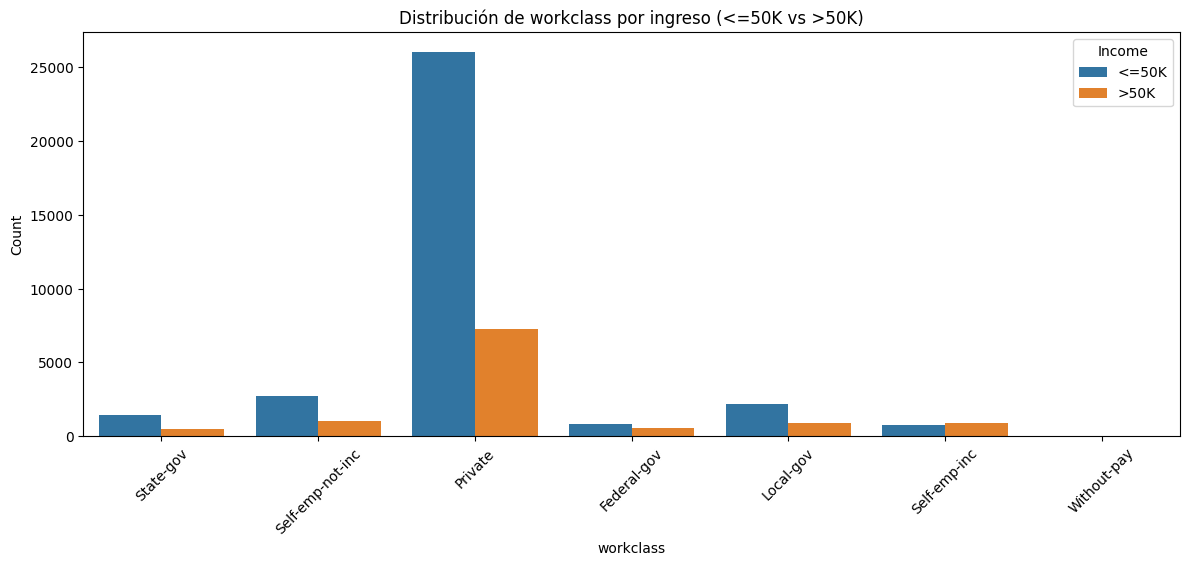

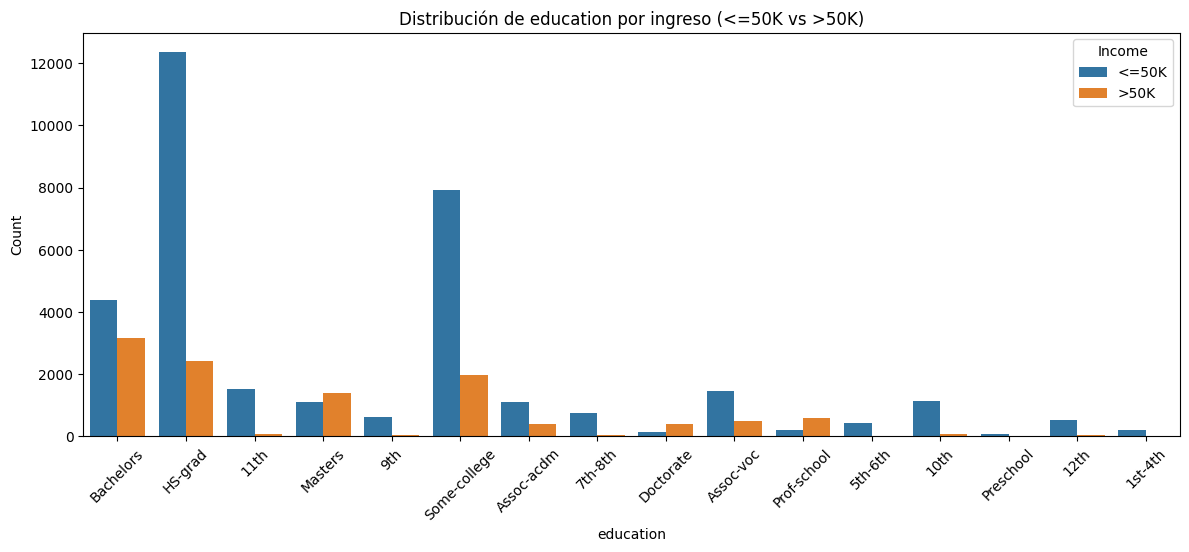

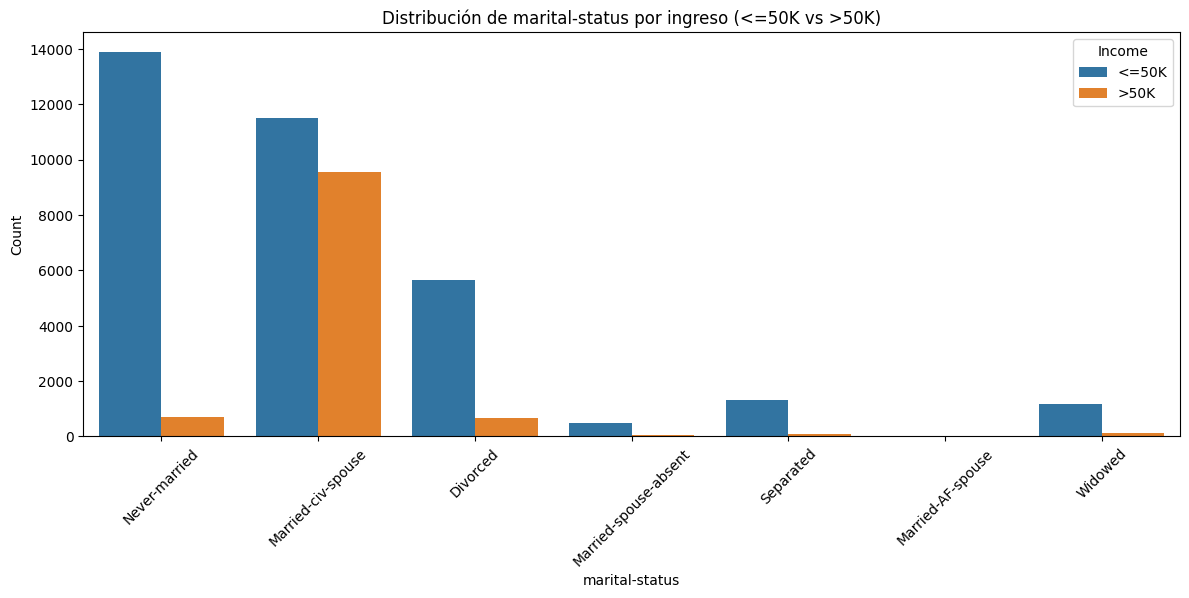

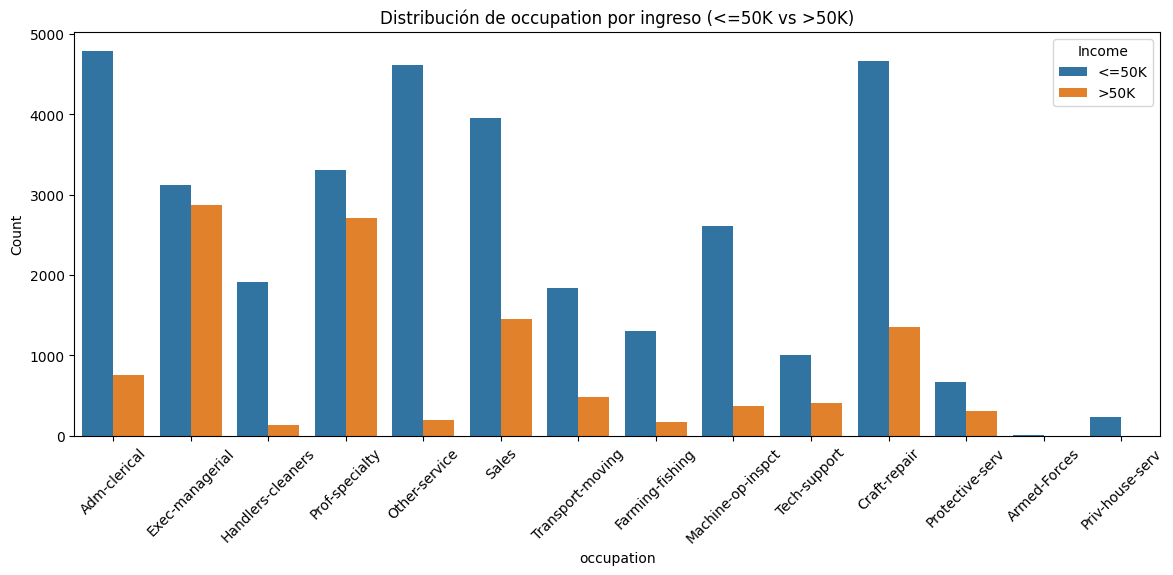

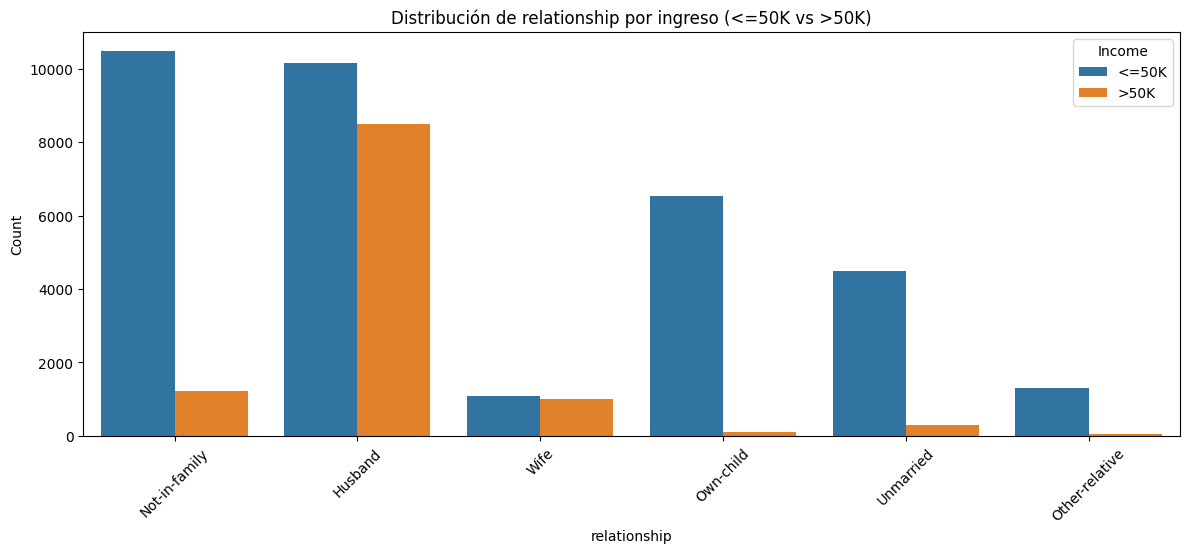

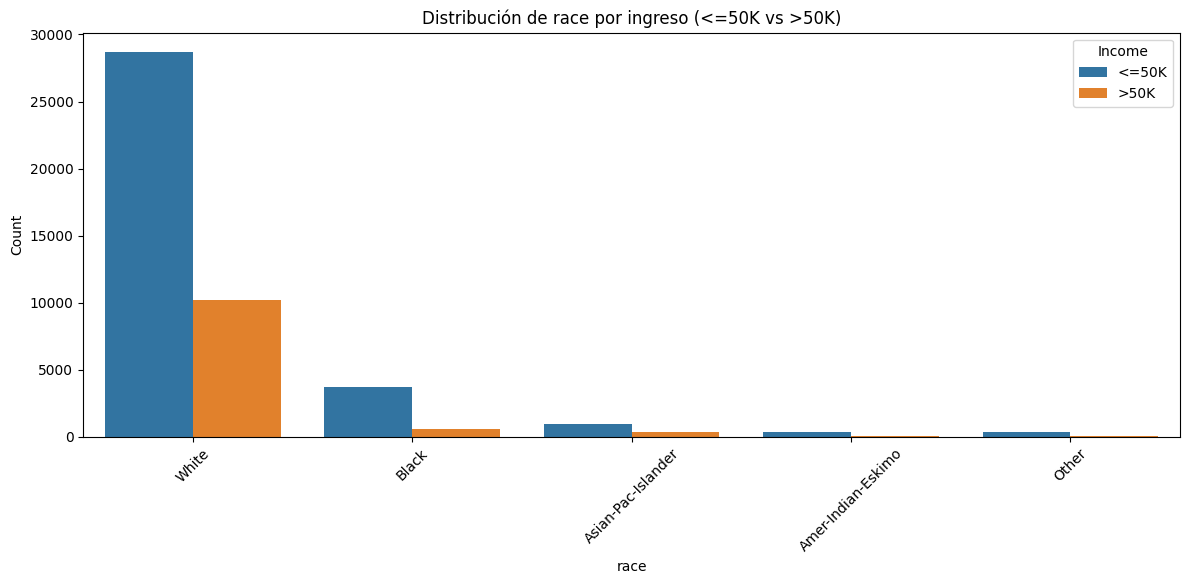

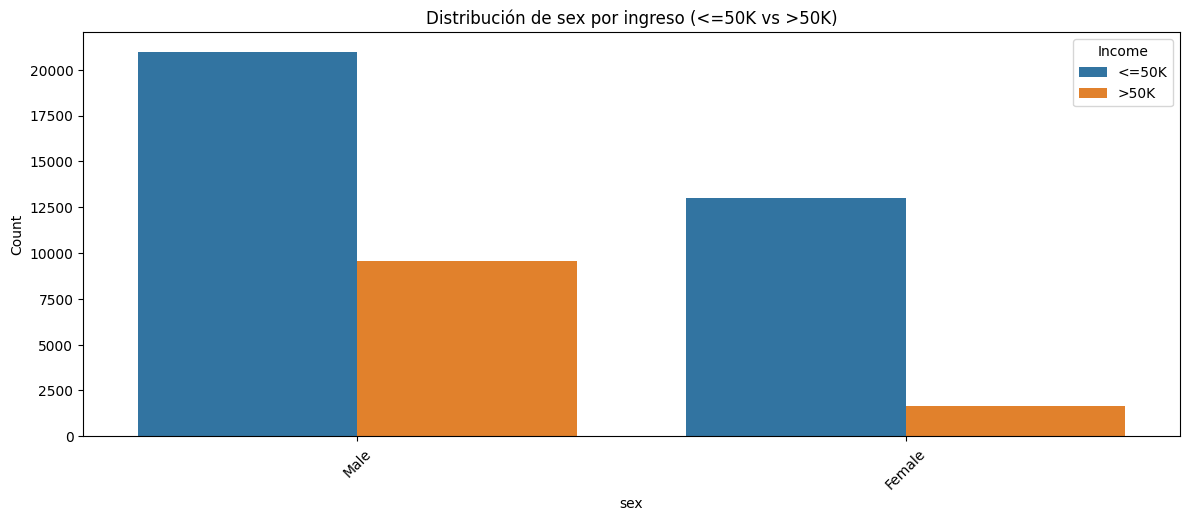

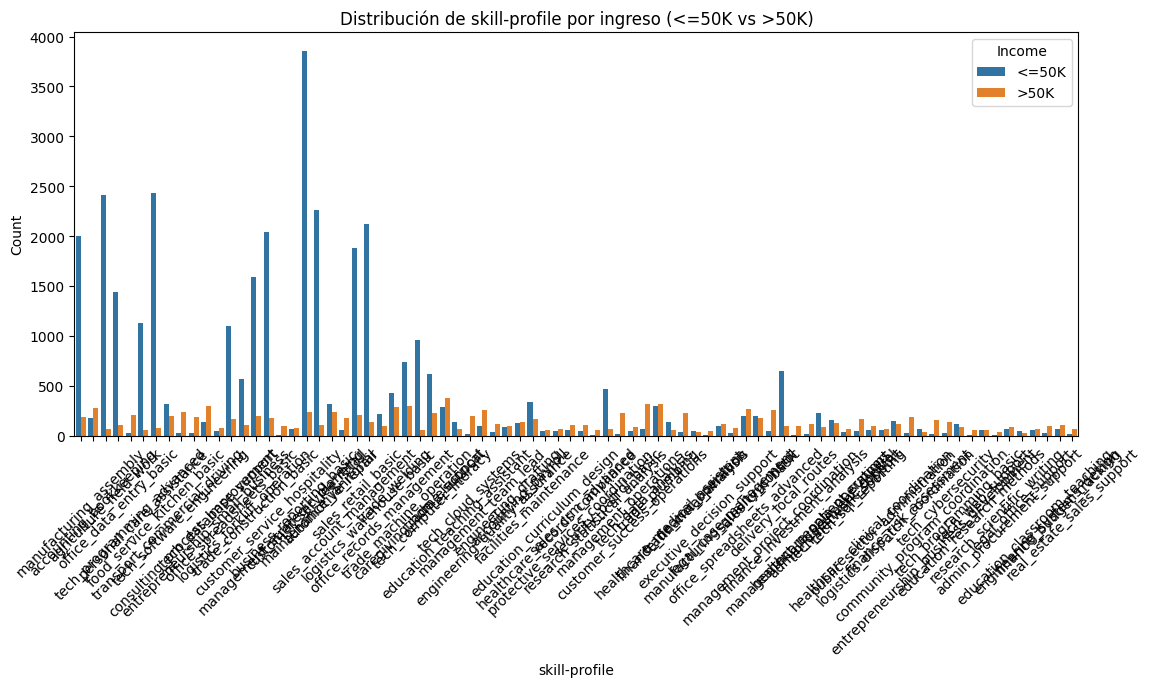

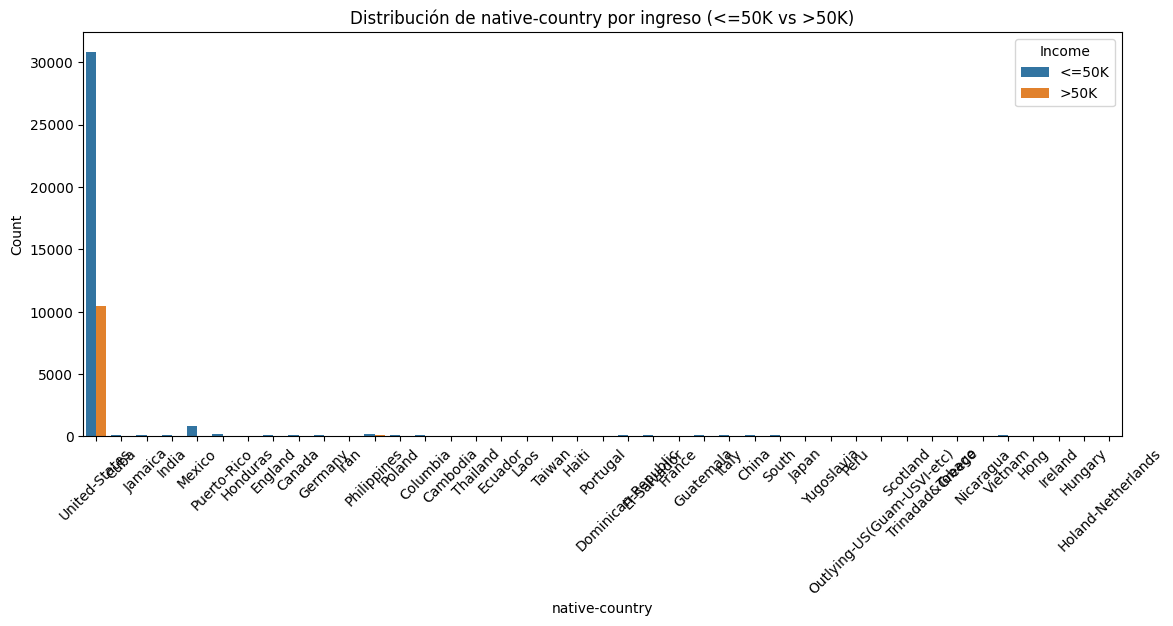

In [6]:
for feature in cat_features.columns:
    plot_categorical_feature(df, feature)

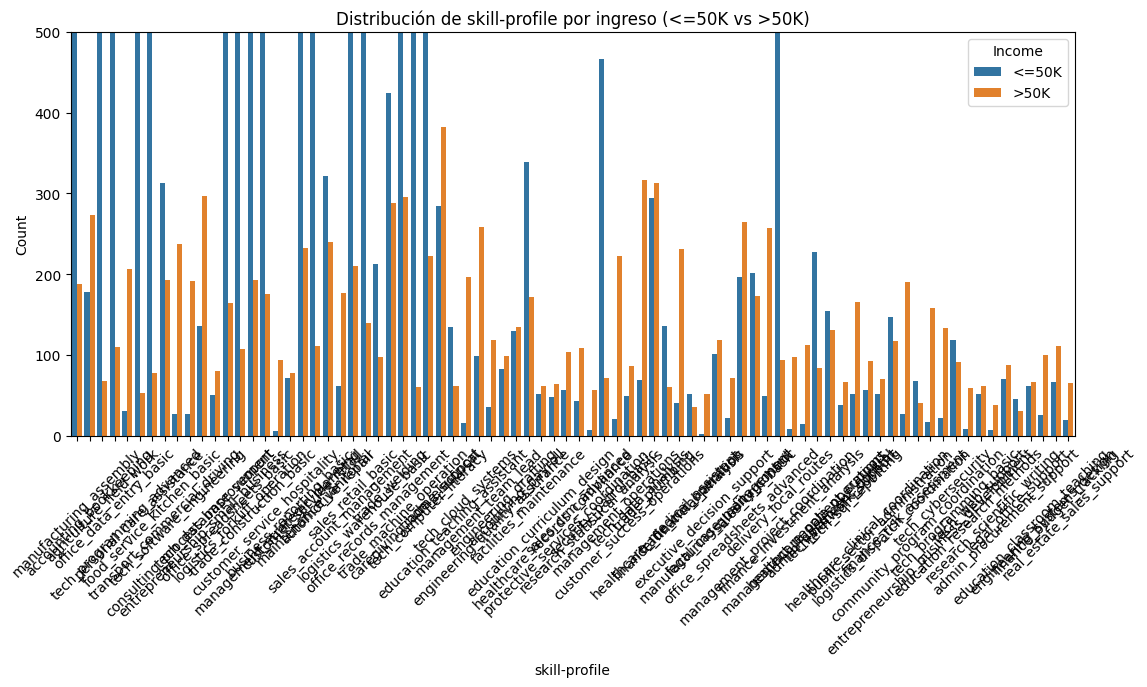

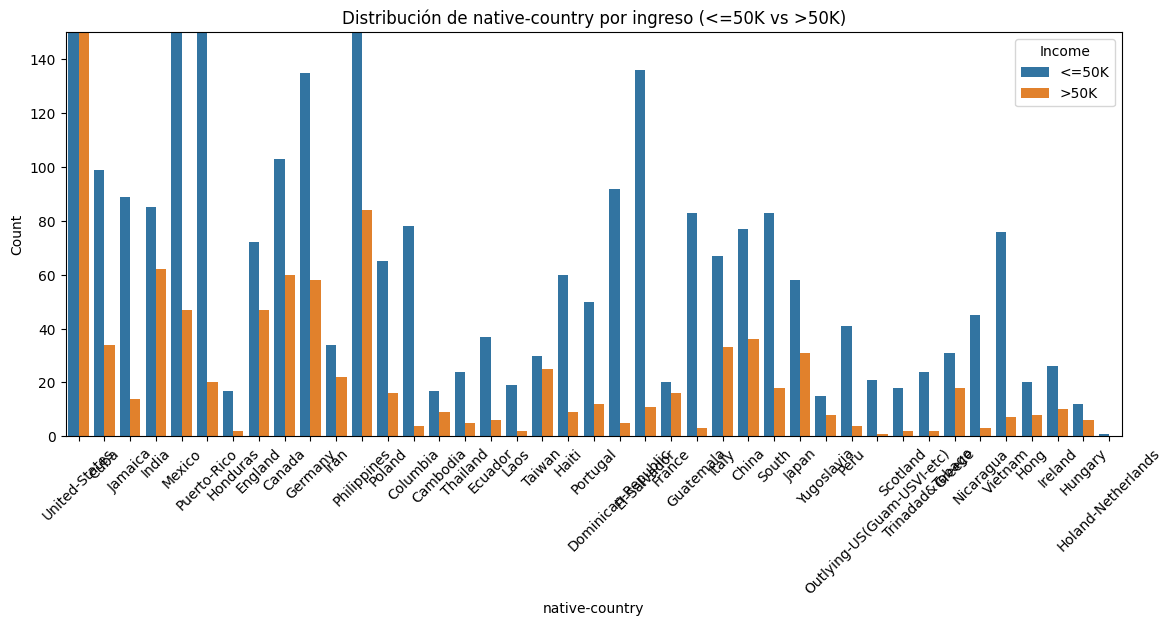

In [7]:
# Se vuelve a plotear las distribuciones de los features skill-profile
# y native-country limitando en el eje y.
plot_categorical_feature(df, "skill-profile", y_top_limit=500)
plot_categorical_feature(df, "native-country", y_top_limit=150)



In [8]:
# Se agrega un análisis de la correlación entre variables categóricas, incluyendo al target

from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    """
    Cramér's V para asociación entre dos variables categóricas.
    """
    x = pd.Series(x).astype("object")
    y = pd.Series(y).astype("object")

    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()
    r, k = tab.shape
    denom = n * (min(r, k) - 1)
    return np.sqrt(chi2 / denom) if denom > 0 else np.nan

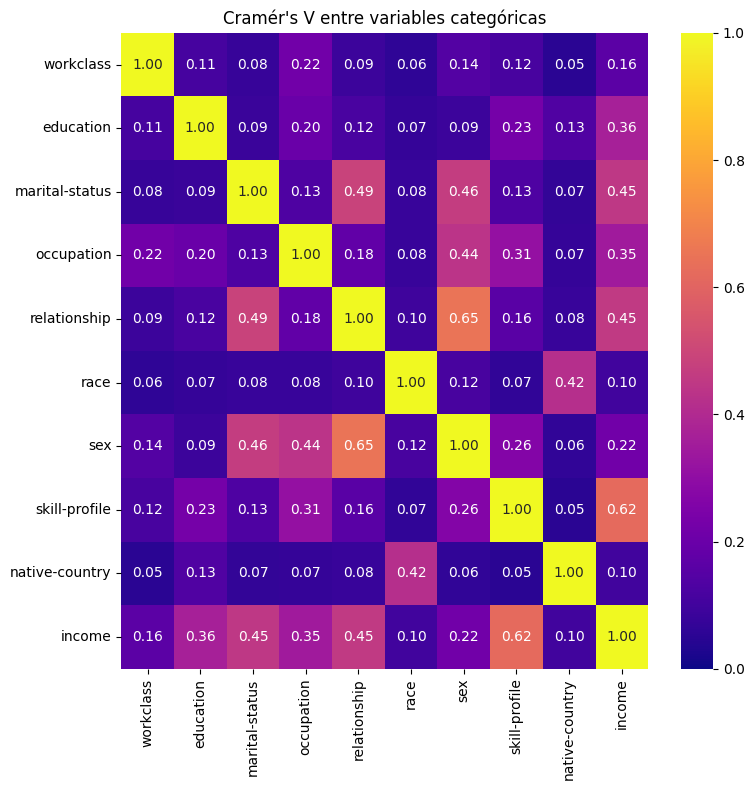

In [9]:
# Se crea una matriz n x n con el cálculo de Cramer's v entre 
# las categóricas (incluyendo al target)
cat_cols = df[["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "skill-profile", "native-country", "income"]]
cat_cols = list(cat_cols)
m = pd.DataFrame(np.eye(len(cat_cols)), index=cat_cols, columns=cat_cols, dtype=float)

for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)):
        v = cramers_v(df[cat_cols[i]], df[cat_cols[j]])
        m.iat[i, j] = v
        m.iat[j, i] = v

plt.figure(figsize=(8, 8))
sns.heatmap(m, cmap="plasma", vmin=0, vmax=1, annot=True, fmt=".2f", )
plt.title("Cramér's V entre variables categóricas")
plt.tight_layout()
plt.show()

In [10]:
cat_features.nunique()

workclass          7
education         16
marital-status     7
occupation        14
relationship       6
race               5
sex                2
skill-profile     80
native-country    41
dtype: int64

In [11]:
df["family-status"] = df["marital-status"] + "_" + df["relationship"]
print(df["marital-status"].value_counts())
print(df["relationship"].value_counts())
print(df["family-status"].nunique())
df["family-status"].value_counts()

marital-status
Married-civ-spouse       21055
Never-married            14598
Divorced                  6297
Separated                 1411
Widowed                   1277
Married-spouse-absent      552
Married-AF-spouse           32
Name: count, dtype: int64
relationship
Husband           18666
Not-in-family     11702
Own-child          6626
Unmarried          4788
Wife               2091
Other-relative     1349
Name: count, dtype: int64
29


family-status
Married-civ-spouse_Husband              18655
Never-married_Not-in-family              6691
Never-married_Own-child                  5864
Divorced_Not-in-family                   3435
Divorced_Unmarried                       2267
Married-civ-spouse_Wife                  2072
Never-married_Unmarried                  1223
Never-married_Other-relative              820
Widowed_Not-in-family                     687
Separated_Unmarried                       618
Separated_Not-in-family                   588
Widowed_Unmarried                         511
Divorced_Own-child                        429
Married-spouse-absent_Not-in-family       282
Married-civ-spouse_Other-relative         184
Married-spouse-absent_Unmarried           169
Divorced_Other-relative                   166
Separated_Own-child                       130
Married-civ-spouse_Own-child              125
Separated_Other-relative                   75
Widowed_Other-relative                     59
Married-spouse-absen

In [12]:
df["education"].value_counts()

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64

In [13]:
df["skill-occupation"] = df["skill-profile"] + "_" + df["occupation"]
print(df["skill-profile"].value_counts())
print(df["occupation"].value_counts())
print(df["skill-occupation"].nunique())
df["skill-occupation"].value_counts()

skill-profile
customer_service_retail          4087
food_service_kitchen_basic       2508
agriculture_field_work           2478
maintenance_janitorial           2376
logistics_warehouse_basic        2257
                                 ... 
legal_office_support               76
education_research_methods         67
research_statistical_analysis      63
executive_decision_support         53
research_scientific_writing        45
Name: count, Length: 80, dtype: int64
occupation
Craft-repair         6020
Prof-specialty       6008
Exec-managerial      5984
Adm-clerical         5540
Sales                5408
Other-service        4808
Machine-op-inspct    2970
Transport-moving     2316
Handlers-cleaners    2046
Farming-fishing      1480
Tech-support         1420
Protective-serv       976
Priv-house-serv       232
Armed-Forces           14
Name: count, dtype: int64
840


skill-occupation
customer_service_retail_Adm-clerical                1287
food_service_kitchen_basic_Other-service             966
customer_service_retail_Other-service                922
customer_service_retail_Sales                        919
manufacturing_assembly_Craft-repair                  805
                                                    ... 
community_program_coordination_Machine-op-inspct       1
executive_decision_support_Tech-support                1
research_statistical_analysis_Sales                    1
management_people_operations_Machine-op-inspct         1
consulting_process_improvement_Machine-op-inspct       1
Name: count, Length: 840, dtype: int64

In [14]:
df["native-country"].value_counts()

native-country
United-States                 41292
Mexico                          903
Philippines                     283
Germany                         193
Puerto-Rico                     175
Canada                          163
India                           147
El-Salvador                     147
Cuba                            133
England                         119
China                           113
Jamaica                         103
South                           101
Italy                           100
Dominican-Republic               97
Japan                            89
Guatemala                        86
Vietnam                          83
Columbia                         82
Poland                           81
Haiti                            69
Portugal                         62
Iran                             56
Taiwan                           55
Greece                           49
Nicaragua                        48
Peru                             45
Ecuador      

Variables numéricas

In [15]:
def plot_numerical_feature(df, feature, y_top_limit=None):
    plt.figure(figsize=(12,5))
    sns.histplot(data=df, x=feature, hue="income", kde=True)
    plt.title(f"Distribución de {feature} por ingreso (<=50K vs >50K)")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.ylim(0, y_top_limit)  # Limitar el eje y si se indica un límite
    plt.tight_layout()
    plt.show()

def plot_numerical_feature_boxplot(df, feature):
    plt.figure(figsize=(12,5))
    sns.boxplot(data=df, x="income", y=feature)
    plt.title(f"Boxplot de {feature} por ingreso (<=50K vs >50K)")
    plt.xlabel("Income")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

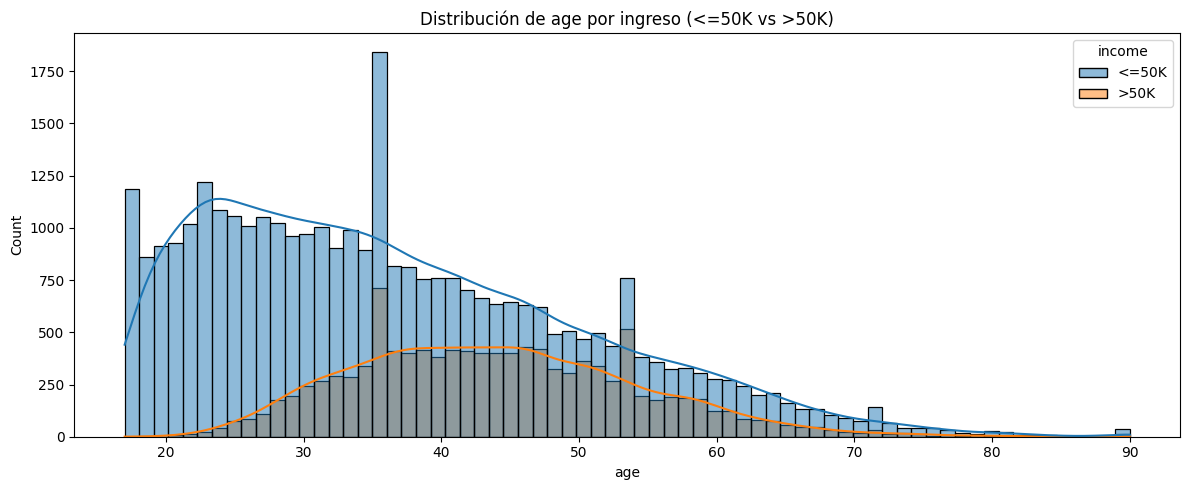

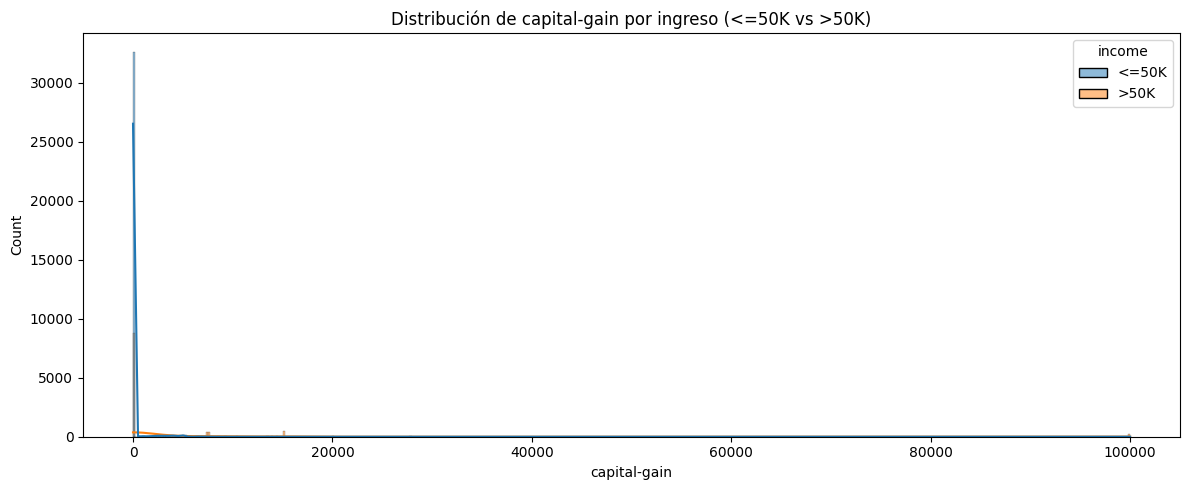

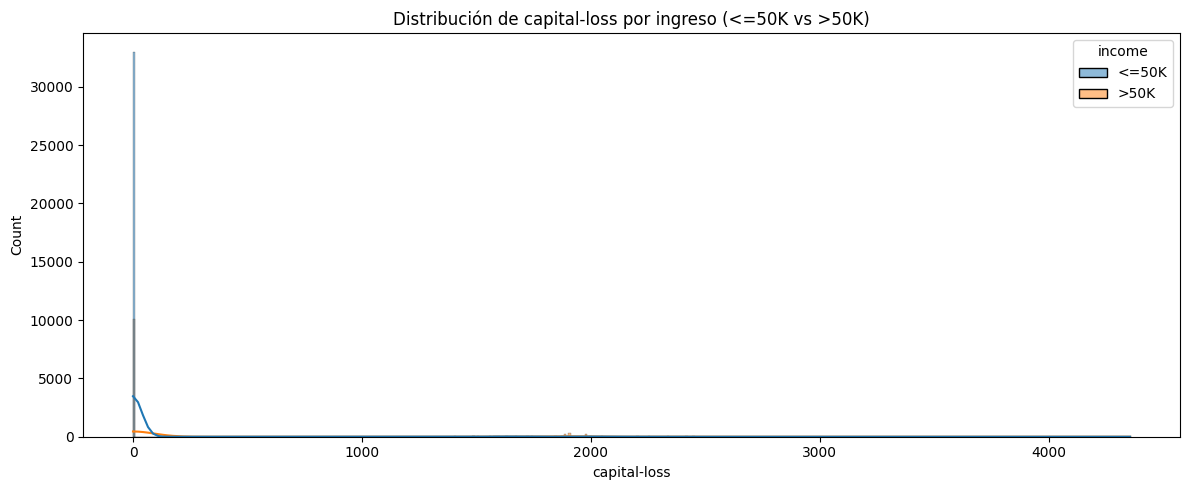

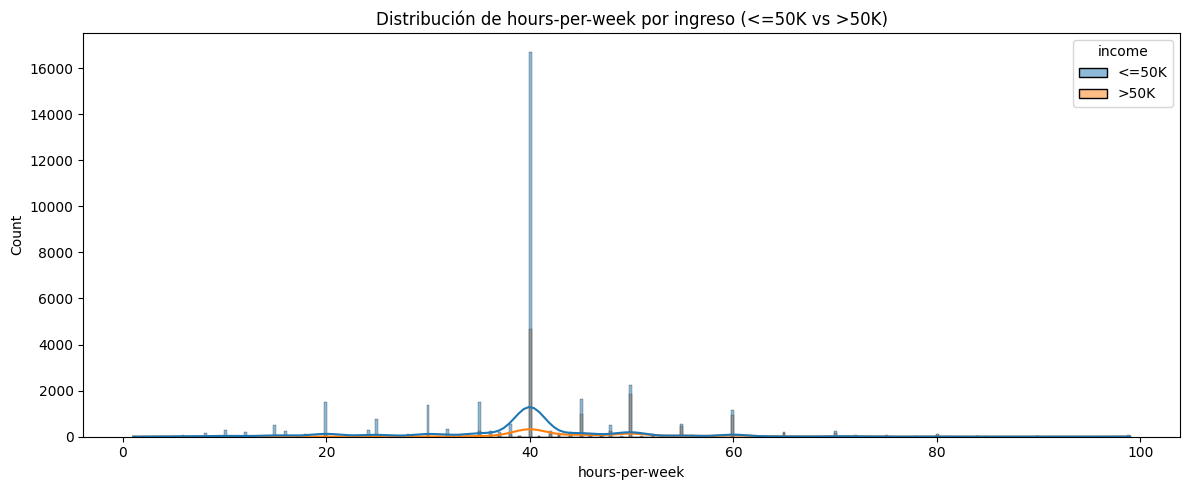

In [16]:
for feature in num_features.columns:
    plot_numerical_feature(df, feature)

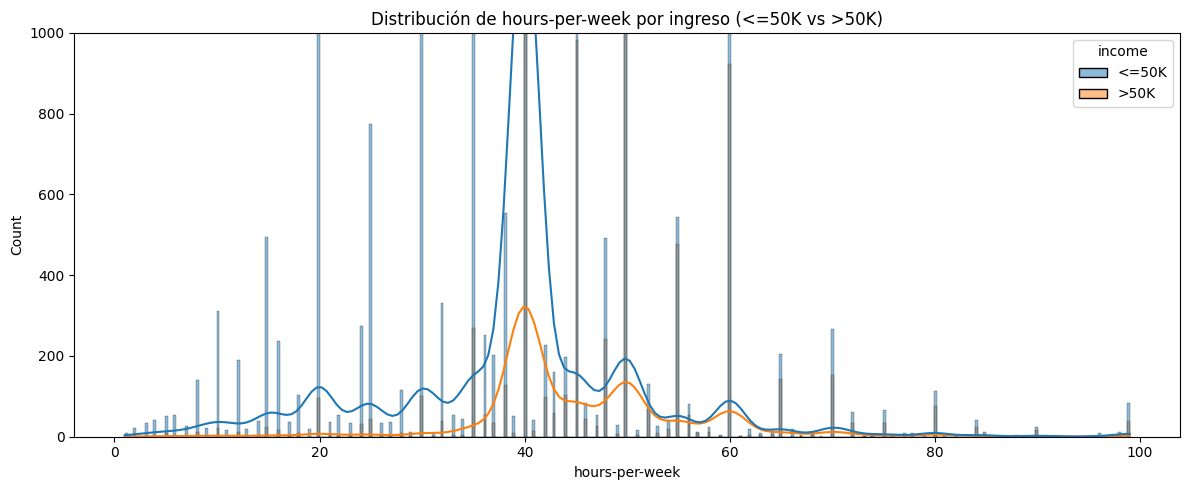

In [17]:
plot_numerical_feature(df, "hours-per-week", y_top_limit=1000)

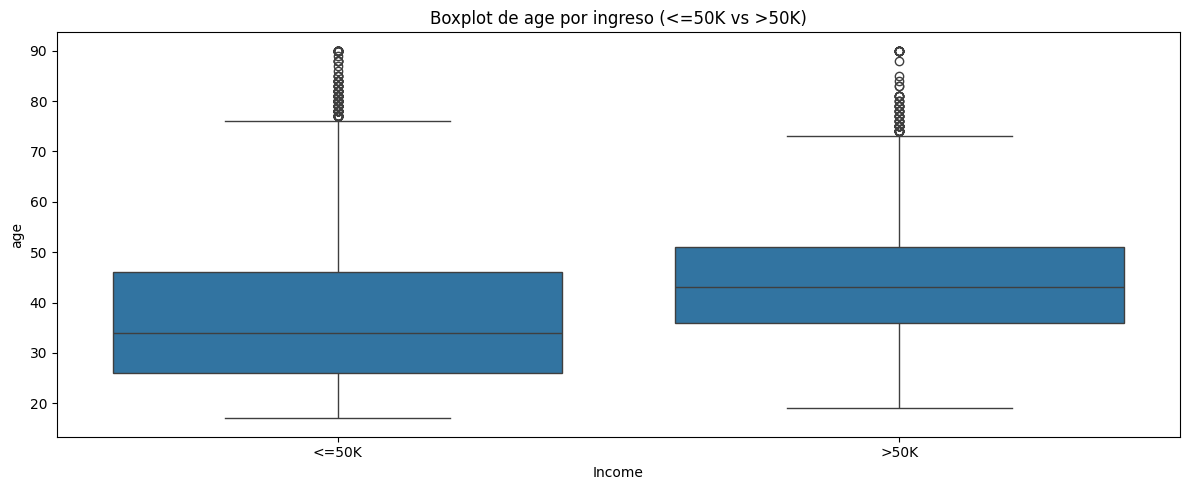

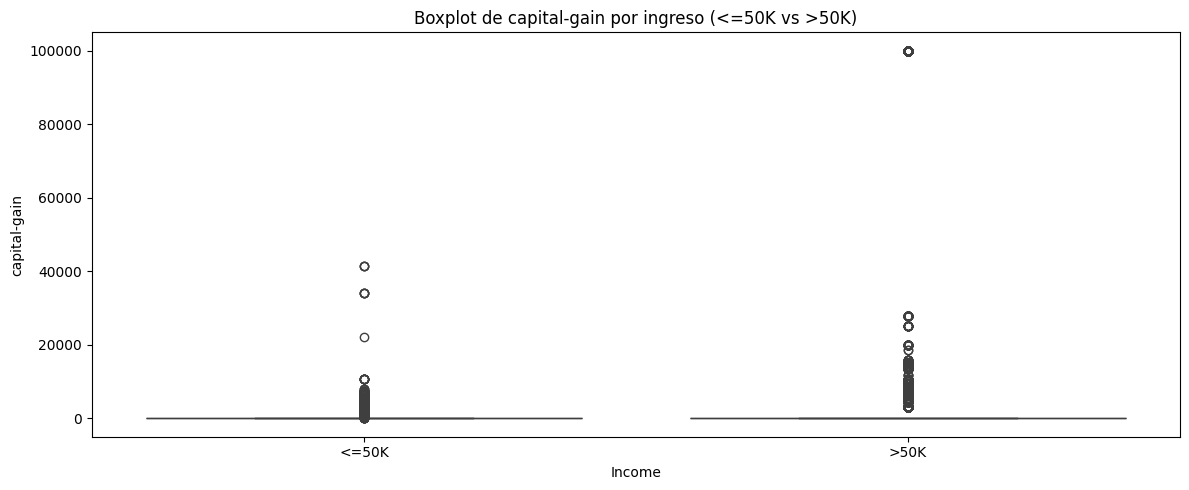

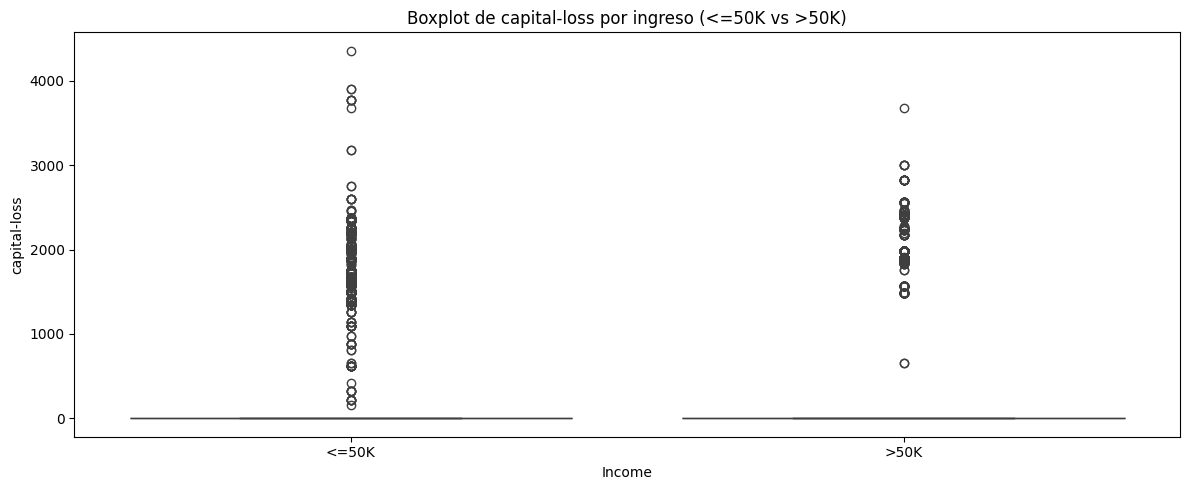

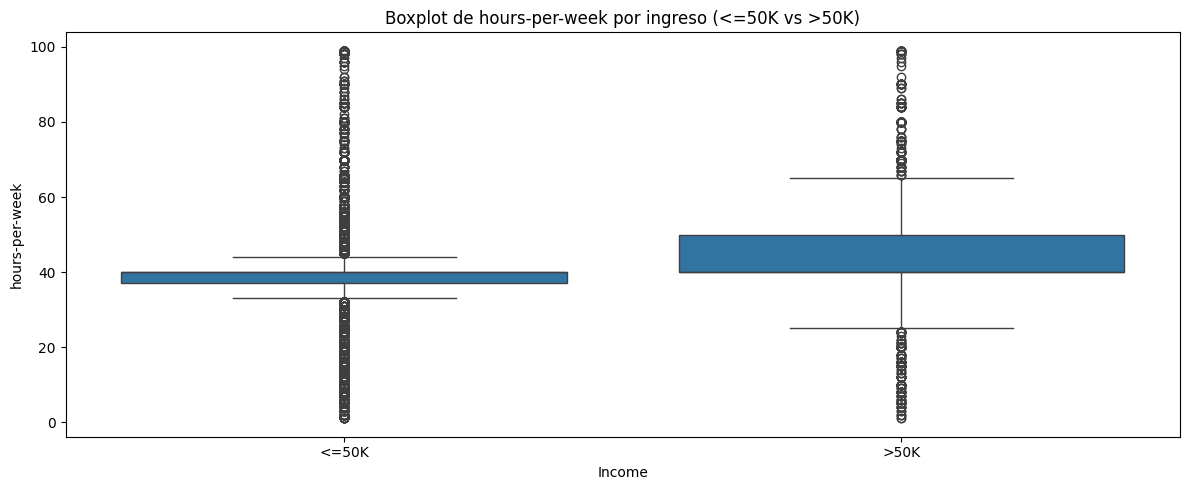

In [18]:
for feature in num_features.columns:
    plot_numerical_feature_boxplot(df, feature)

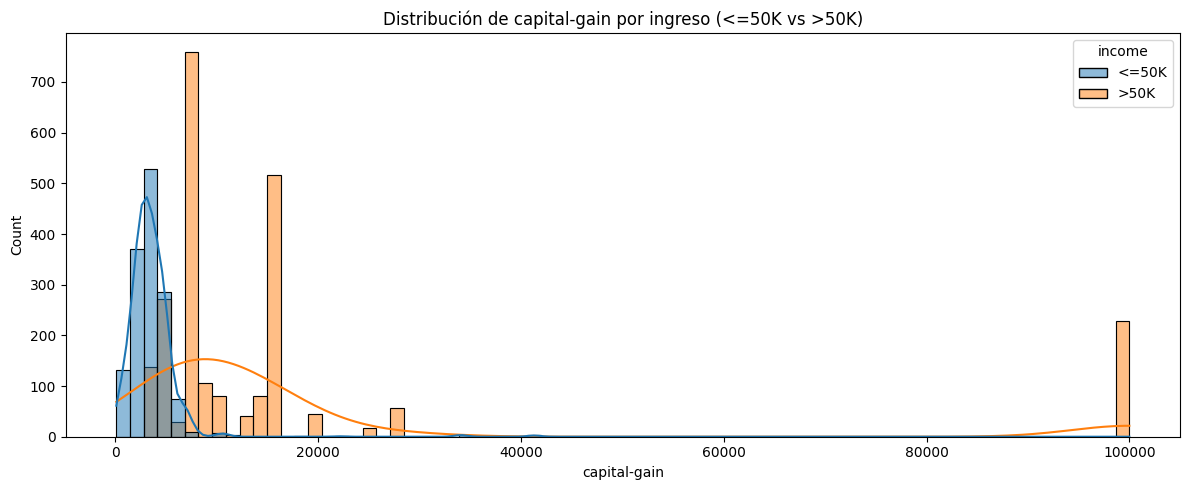

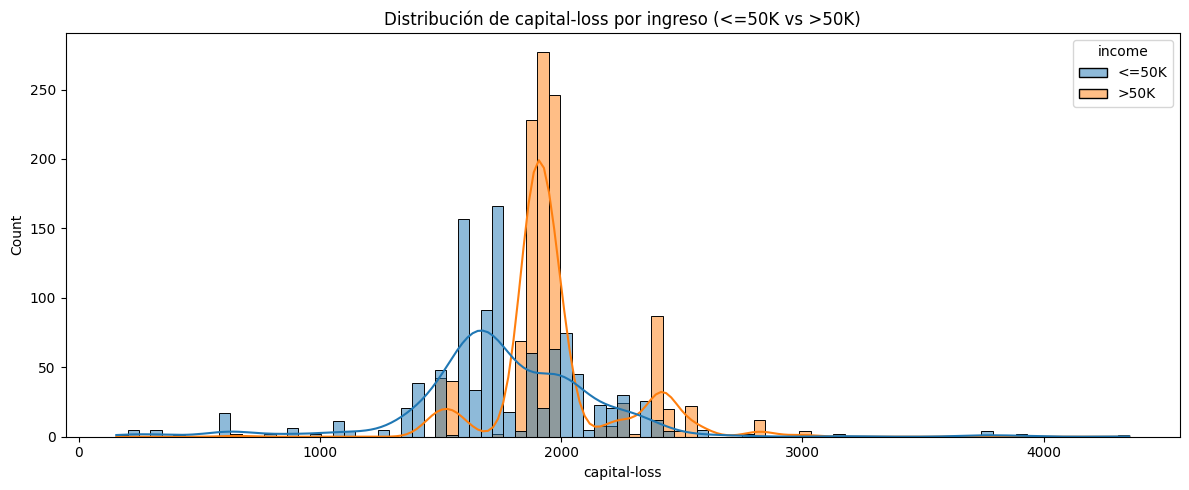

capital-gain tiene 3790 valores distintos a 0 (8.38%)
capital-loss tiene 2140 valores distintos a 0 (4.73%)


In [19]:
n_capital_gain_zero = df[df['capital-gain'] == 0].shape[0]
n_capital_loss_zero = df[df['capital-loss'] == 0].shape[0]

# Se filtran todos estos registros con 0 y se vuelven a graficar.
df_filtered_gain = df[(df['capital-gain'] != 0)]
df_filtered_loss = df[(df['capital-loss'] != 0)]
plot_numerical_feature(df_filtered_gain, "capital-gain")
plot_numerical_feature(df_filtered_loss, "capital-loss")

total_rows = df.shape[0]
print(f"capital-gain tiene {len(df_filtered_gain)} valores distintos a 0 ({len(df_filtered_gain)/total_rows*100:.2f}%)")
print(f"capital-loss tiene {len(df_filtered_loss)} valores distintos a 0 ({len(df_filtered_loss)/total_rows*100:.2f}%)")

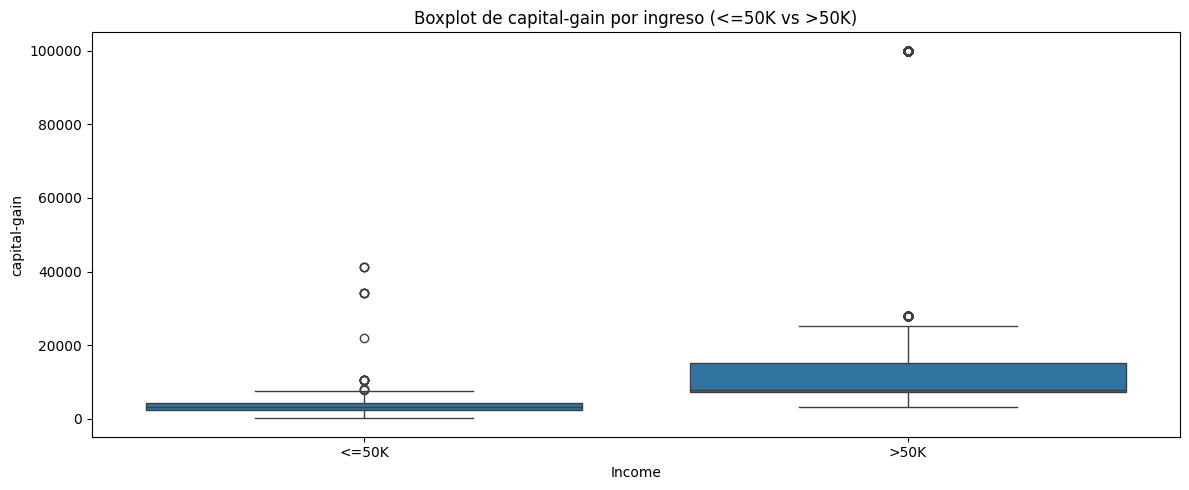

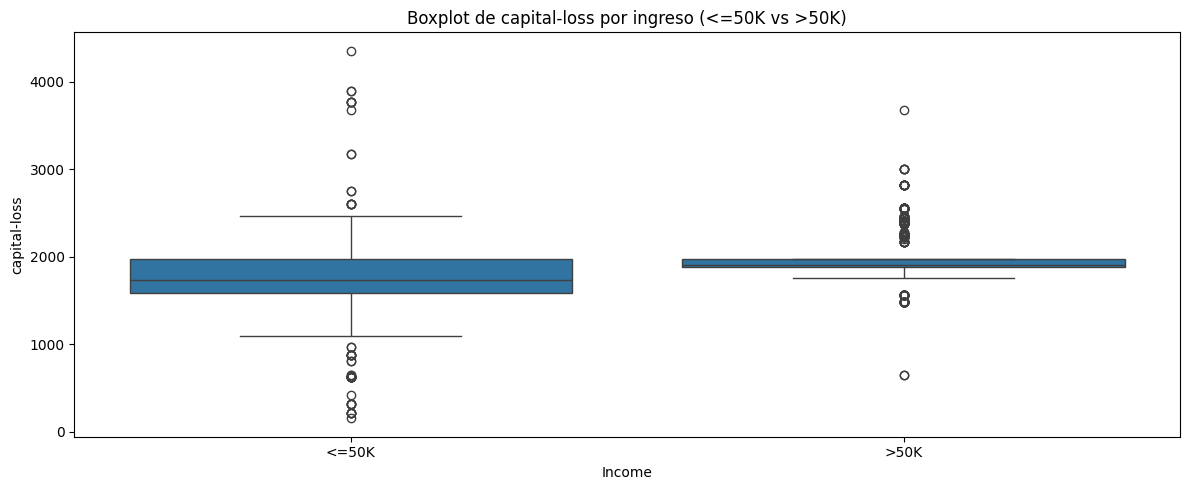

In [20]:
plot_numerical_feature_boxplot(df_filtered_gain, "capital-gain")
plot_numerical_feature_boxplot(df_filtered_loss, "capital-loss")

In [21]:
df.describe()

,age,capital-gain,capital-loss,hours-per-week
count,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1101.430344,88.595418,40.938017
std,13.217870,7506.430084,404.956092,12.007508
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


Se observa de manera generalizada que todos los features muestran una relación de sus valores con el target que puede influir en la predicciones. No hay valores nulos, pero sí existen outliers, principalmente en capital-gain y capital-loss, incluso analizándolo sin aquellos registros que tienen estos atributos en 0. En `capital-gain` existen varios registros con valor 99999, lo que podría deberse a una limitación el formulario o a un error, sin embargo en primera instancia no se descartarán, ya que se puede pensar que son valores truncados.

Va a ser necesario tratar estos valores outliers de alguna forma particular, ya que el rango dinámico que posee el atributo puede ser un problema para la red aplicando escalado estándar. Tanto para `capital-gain` como `capital-loss`, más del 90% de lo registros valen 0, pero parece que solo tener un valor mayor a 0 tiene impacto sobre el target.

Se analiza el comportamiento para la diferencia de estos.

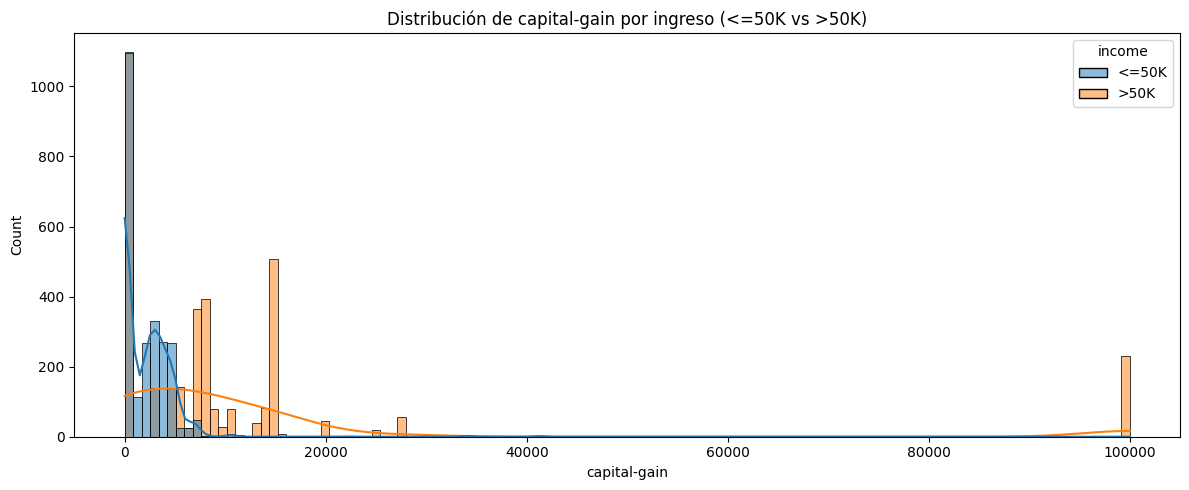

In [22]:
df_filtered = df[(df['capital-gain'] != 0) | (df['capital-loss'] != 0)]
df_filtered["net-capital"] = df_filtered["capital-gain"] - df_filtered["capital-loss"]

plot_numerical_feature(df_filtered, "capital-gain")

La diferencia entre ambos antributos muestra un comportamiento claro, pero no muy distinto a lo que se ve con los atributos crudos.

Con el EDA realizado, se definen el razonamiento y las conclusiones para cada atributo del dataset.
- `age`:

    Variable numérica entera, con valores entre 17 y 90. A simple vista, se observa que a mayor edad, mayor es la proporción de `income` > 50k$.

    Se decide solo aplicar un escalado estándar.

- `workclass`:

    Variable categórica nominal, con 7 categorías distintas. Se considera cardinalidad moderada y que no hay una relación u orden entre cada clase.

    Se decide usar One-Hot Encoding

- `education`:

    Variable categórica ordinal, con 16 categorías distintas. Se considera una cardinalidad alta pero pero con un orden natural claro. 

    Se considera que no está mal usar Ordinal Encoding en principio y pero termina eligiéndose Embeddings, ya que por consigna se indica considerar 10 categorías como una cardinalidad alta y el orden natural no varía uniformemente.

- `marital-status`:

    Variable categórica nominal, con 7 categorías únicas. Se considera una cardinalidad moderada sin orden natural claro, aunque si podría decirse que algunas categorías son más próximas entre sí (Por ejemplo: "Divorce" estaría más cerca de "Widowed" que de "Never-married"), por lo que podría ser un candidato a usar embeddings.

    Por la cardinalidad reducida y un orden no tan claro en la relación entre categorías, se decide usar One-Hot Encoding.

- `relationship`:

    Variable categórica nominal, con 6 categorías únicas. El caso es muy similar al atributo anterior (`marital-status`), y por consistencia se decide hacer lo mismo. Se exploró la posibilidad de hacer una codificación con embeddings para la combinación de ambos atributos, ya que tienen una correlación moderada y contextualmente se entiende que pueden estar relacionadas, pero no se decide aplicarlo en primera instancia.

    Se decide usar One-Hot Encoding.

- `occupation`:

    Variable categórica nominal, con 14 categorías únicas. La cardinalidad es alta y no hay un orden claro entre las clases, pero sí pueden existir relaciones semánticas entre ellas.

    Se decide usar Embeddings.

- `race`:

    Variable categórica nominal, con 5 categorías únicas. Con cardinalidad baja y es importante tratarlas sin un orden.

    Se elige One-Hot Encoding


- `sex`:

    Variable categórica nominal binaria.

    Se elige Label Encoding binario.


- `capital-gain`:

    Variable numérica entera, con rango de 0 a 99999. Se decide crear un flag indicando si tiene valor mayor a 0 o no y expresarlo una escala logarítmica para luego aplicar el escalado. Esto es porque que el dato sea mayor a 0, parece tener un impacto en el target y para que las neuronas no se saturen con los outliers en 99999.

    En resumen, se crea un flag y se aplica un escalado estándar al logaritmo (se usa log(1 + x) para evitar el log de 0).


- `capital-loss`:

    Variable numérica entera, con rango de 0 a 4356. Se decide hacer lo mismo que para `capital-gain`, ya que si bien no aparecen los outliers truncados a 99999, si existen valores bastante grandes para un atributo cuyos valores son más del 95% iguales a 0.

    En resumen, se crea un flag y se aplica un escalado estándar al logaritmo (se usa log(1 + x) para evitar el log de 0).


- `hours-per-week`:

    Variable numérica entera, con rango entre 1 y 99, con gran concentración de registros en 40 (horas) pero con varianza real.

    Se decide usar escalado estándar.


- `skill-profile`:

    Variable categórica nominal, con 80 categorías únicas. La cardinalidad es muy alta y no hay un orden claro entre las clases, pero sí existen relaciones semánticas entre ellas.

    Es un candidato ideal para usar Embeddings.


- `native-country`:

    Variable categórica nominal, con 41 categorías únicas. La cardinalidad es muy alta y tienen un orden, pero sí pueden existir relaciones entre ellas, como geográficas, económicas o culturales. Casi todos los datos son de la clase Estados Unidos y existe una clase que aparece solo una vez en todo el dataset. Una opción es agrupar por regiones y usar OHE, pero a fines de aprender como los embeddings manejan estos casos, se decide avanzar con esta opción sin más preprocesamiento.

    Se decide usar Embeddings.
    

El criterio para seleccionar la dimensionalidad de los embeddings será el propuesto por el framework descripto en el paper [fastai: A Layered API for Deep Learning](https://arxiv.org/pdf/2002.04688) que sugiere:
$$d = min(600, round(1.6 C^{0.56}))$$

donde C es la cardinalidad del atributo. Obtenido el valor de $d$, se probará la red con el valor entero más cercano y la potencia de 2 inmediata superior. De esta manera, para aquellas columnas en las que se decidió usar embeddings quedarían con la siguiente dimensionalidad:
- `education`: $C = 16 \implies d = 7.558 \approx 8$
- `occupation`: $C = 14 \implies d = 7.014 \approx 7$
- `skill-profile`: $C = 80 \implies d = 18.614 \approx 19$
- `native-country`: $C = 41 \implies d = 12.802 \approx 12$

-----

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

#### Resolución

Definido el análisis de los datos, se separa el dataset y se aplican las transformaciones.



In [23]:
df_tr
X_train = df_tr.drop("income", axis=1)
y_train = (df_tr["income"] == ">50K").astype(int) # Para convertirlo en "booleano"

X_val = df_val.drop("income", axis=1)
y_val = (df_val["income"] == ">50K").astype(int) # Para convertirlo en "booleano"

X_train.shape, y_train.shape, X_val.shape, y_val.shape

((30162, 13), (30162,), (15060, 13), (15060,))

In [24]:
embeddings_cols = ["education", "occupation", "skill-profile", "native-country"]

# Diccionearios de mapeos y tamaños
emb_mappings = {}
emb_sizes = {}
# Conversión a embeddings para cada columna
for col in embeddings_cols:
    # Se obtienen índices para las categorís del dataset completo
    unique_cats = pd.concat([X_train[col], X_val[col]]).unique()

    cat_to_idx = {cat: idx for idx, cat in enumerate(unique_cats)}

    emb_mappings[col] = cat_to_idx
    emb_sizes[col] = len(unique_cats)

    X_train[col + '_idx'] = X_train[col].map(cat_to_idx)
    X_val[col + '_idx'] = X_val[col].map(cat_to_idx)

print("Categorías para embeddings: ")
for col, size in emb_sizes.items():
    print(f"    {col}: {size}")

Categorías para embeddings: 
    education: 16
    occupation: 14
    skill-profile: 80
    native-country: 41


In [25]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [26]:
# One-Hot Encodings ------------
ohe_cols = ['workclass', 'marital-status', 'relationship', 'race']

X_train_ohe = pd.get_dummies(
    X_train,
    columns=ohe_cols,
    # drop_first=True,
    dtype=int
)
X_val_ohe = pd.get_dummies(
    X_val,
    columns=ohe_cols,
    # drop_first=True,
    dtype=int
)
# Asegurar que tengan las mismas columnas
X_val_ohe = X_val_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)


# Label Encodings -----------
le_sex = LabelEncoder()
X_train_ohe["encoded_sex"] = le_sex.fit_transform(X_train["sex"])
X_val_ohe["encoded_sex"] = le_sex.transform(X_val["sex"])

X_train_ohe.head()

,age,education,occupation,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,education_idx,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,encoded_sex
0,39,Bachelors,Adm-clerical,Male,2174,0,40,manufacturing_assembly,United-States,0,...,0,0,0,0,0,0,0,0,1,1
1,50,Bachelors,Exec-managerial,Male,0,0,13,accounting_bookkeeping,United-States,0,...,0,0,0,0,0,0,0,0,1,1
2,38,HS-grad,Handlers-cleaners,Male,0,0,40,agriculture_field_work,United-States,1,...,0,0,0,0,0,0,0,0,1,1
3,53,11th,Handlers-cleaners,Male,0,0,40,office_data_entry_basic,United-States,2,...,0,0,0,0,0,0,1,0,0,1
4,28,Bachelors,Prof-specialty,Female,0,0,40,tech_programming_advanced,Cuba,0,...,0,0,0,1,0,0,1,0,0,0


In [27]:
# Transformaciones numéricas --------

# Escalado para age
sc_age = StandardScaler()
X_train_ohe["scaled_age"] = sc_age.fit_transform(X_train[["age"]])
X_val_ohe["scaled_age"] = sc_age.transform(X_val[["age"]])

# Escalado para hours-per-week
sc_hpw = StandardScaler()
X_train_ohe["scaled_hpw"] = sc_hpw.fit_transform(X_train[["hours-per-week"]])
X_val_ohe["scaled_hpw"] = sc_hpw.transform(X_val[["hours-per-week"]])

# Flag, logaritmo y escalado para capital-gain
X_train_ohe["has_capital_gain"] = (X_train["capital-gain"] > 0).astype(int)
X_val_ohe["has_capital_gain"] = (X_val["capital-gain"] > 0).astype(int)

X_train_ohe["capital_gain_log"] = np.log1p(X_train["capital-gain"])
X_val_ohe["capital_gain_log"] = np.log1p(X_val["capital-gain"])

sc_gain = StandardScaler()
X_train_ohe["scaled_gain"] = sc_gain.fit_transform(
    X_train_ohe[["capital_gain_log"]]
)
X_val_ohe["scaled_gain"] = sc_gain.transform(
    X_val_ohe[["capital_gain_log"]]
)

# Flag, logaritmo y escalado para capital-loss
X_train_ohe["has_capital_loss"] = (X_train["capital-loss"] > 0).astype(int)
X_val_ohe["has_capital_loss"] = (X_val["capital-loss"] > 0).astype(int)

X_train_ohe["capital_loss_log"] = np.log1p(X_train["capital-loss"])
X_val_ohe["capital_loss_log"] = np.log1p(X_val["capital-loss"])

sc_loss = StandardScaler()
X_train_ohe["scaled_loss"] = sc_loss.fit_transform(
    X_train_ohe[["capital_loss_log"]]
)
X_val_ohe["scaled_loss"] = sc_loss.transform(
    X_val_ohe[["capital_loss_log"]]
)

# Debería mostrar 8 columnas más
X_train_ohe.head()

,age,education,occupation,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,education_idx,...,race_White,encoded_sex,scaled_age,scaled_hpw,has_capital_gain,capital_gain_log,scaled_gain,has_capital_loss,capital_loss_log,scaled_loss
0,39,Bachelors,Adm-clerical,Male,2174,0,40,manufacturing_assembly,United-States,0,...,1,1,0.042796,-0.077734,1,7.684784,2.809634,0,0.0,-0.222715
1,50,Bachelors,Exec-managerial,Male,0,0,13,accounting_bookkeeping,United-States,0,...,1,1,0.880288,-2.331531,0,0.000000,-0.301013,0,0.0,-0.222715
2,38,HS-grad,Handlers-cleaners,Male,0,0,40,agriculture_field_work,United-States,1,...,1,1,-0.033340,-0.077734,0,0.000000,-0.301013,0,0.0,-0.222715
3,53,11th,Handlers-cleaners,Male,0,0,40,office_data_entry_basic,United-States,2,...,0,1,1.108695,-0.077734,0,0.000000,-0.301013,0,0.0,-0.222715
4,28,Bachelors,Prof-specialty,Female,0,0,40,tech_programming_advanced,Cuba,0,...,0,0,-0.794697,-0.077734,0,0.000000,-0.301013,0,0.0,-0.222715


In [28]:
# Se seleccionan los features para la red

# Columnas de índices para los embeddings
emb_features = ["education_idx", "occupation_idx", "skill-profile_idx", "native-country_idx"]

# Se toman todas las demás columnas (numéricas despues de la transformacion)
oth_features = [
    "scaled_age",
    "scaled_hpw",
    "has_capital_gain",
    "scaled_gain",
    "has_capital_loss",
    "scaled_loss",
    "encoded_sex"
] + [col for col in X_train_ohe.columns if any(
    col.startswith(prefix) for prefix in ["workclass_", "marital-status_", "relationship_", "race_"]
)]

print(f"\nFeatures con embeddings: {len(emb_features)}")
print(f"Otras features: {len(oth_features)}")


Features con embeddings: 4
Otras features: 32


In [29]:
import torch

In [30]:
# Las columnas de entrada para los embeddings son índices enteros 
X_train_emb = X_train_ohe[emb_features].values.astype(np.int64)
X_train_oth = X_train_ohe[oth_features].values.astype(np.float32)

X_val_emb = X_val_ohe[emb_features].values.astype(np.int64)
X_val_oth = X_val_ohe[oth_features].values.astype(np.float32)

y_train_arr = y_train.values.astype(np.float32)
y_val_arr = y_val.values.astype(np.float32)

# Tensores para pytprch
X_train_emb_tensor = torch.tensor(X_train_emb, dtype=torch.long)
X_train_oth_tensor = torch.tensor(X_train_oth, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_arr, dtype=torch.float32).unsqueeze(1)

X_val_emb_tensor = torch.tensor(X_val_emb, dtype=torch.long)
X_val_oth_tensor = torch.tensor(X_val_oth, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_arr, dtype=torch.float32).unsqueeze(1)


print(X_train_emb_tensor.shape, X_train_oth_tensor.shape, y_train_tensor.shape)
print(X_val_emb_tensor.shape, X_val_oth_tensor.shape, y_val_tensor.shape)


torch.Size([30162, 4]) torch.Size([30162, 32]) torch.Size([30162, 1])
torch.Size([15060, 4]) torch.Size([15060, 32]) torch.Size([15060, 1])


In [31]:
from torch.utils.data import Dataset, DataLoader

In [32]:
# Crear dataset y dataloader
class AdultDataset(Dataset):
    def __init__(self, emb_features, oth_features, targets):
        self.emb_features = emb_features
        self.oth_features = oth_features
        self.targets = targets

    def __len__(self):
        return len(self.targets)
    
    def __getitem__(self, idx):
        return {
            'emb': self.emb_features[idx],
            'oth': self.oth_features[idx],
            'target': self.targets[idx],
        }

train_dataset = AdultDataset(X_train_emb_tensor, X_train_oth_tensor, y_train_tensor)
val_dataset = AdultDataset(X_val_emb_tensor, X_val_oth_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)


Tomando como concluído el análisis de los datos y su preprocesamiento para alimentar la red neuronal, lo siguiente es definir la configuración arquitectónica de la red, hiperparámetros, función de costo y demás consideraciones del entrenamiento y optimización (ya se definió un batch size de 256 al crear el dataloader).

- Red neuronal -> Dos capas ocultas con 256 y 128 neuronas respectivamente, y función de activación ReLU.
- Dropout -> 0.3
- Optimizador -> Adam mini-batch
- Learning rate -> 0.001
- Batch size -> 256
- Función de costo -> Binary cross entropy loss (Se usa `BCEWithLogitsLoss` que combina la BCELoss con una sigmoide internamente, y al documentación oficial indica que es más estable)
- Epochs -> 100 con early stopping implementado (patience=10)
- Métricas -> Accuracy, F1-Macro y classification report


In [47]:
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [41]:
class AdultIncomeClassifier(nn.Module):
    def __init__(self, emb_sizes, other_features_sizes):
        """
        Args:
            emb_sizes: dict con el tamaño de cada embedding (número de categorías)
            other_features_sizes: número de features numéricas/one-hot
        """
        super().__init__()

        # Primero se crean las capas de mbeddings
        self.embeddings = nn.ModuleDict()
        total_emb_dim = 0
        for col, (n, emb_dim) in emb_sizes.items():
            self.embeddings[col] = nn.Embedding(n, emb_dim)
            total_emb_dim += emb_dim
        # Debería quedar el diccionario así:
        # {
        #     "education": nn.Embedding(16, 8),
        #     "occupation": nn.Embedding(14, 7),
        #     "skill-profile": nn.Embedding(80, 19),
        #     "native-country": nn.Embedding(41, 12)
        # }
        input_dim = total_emb_dim + other_features_sizes

        self.hl1_size = 256
        self.hl2_size = 128

        self.fc1 = nn.Linear(input_dim, self.hl1_size)
        self.fc2 = nn.Linear(self.hl1_size, self.hl2_size)
        self.output = nn.Linear(self.hl2_size, 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x_emb, x_other):
        """
        Args:
            x_emb: tensor con los índices para los embeddings (batch_size x n_emb)
            x_other: tensor con las otras features numéricas o categóricas codificadas (batch_size x n_other)
        """
        # POr cada columna, pasar por su embedding y concatenar
        emb_outputs = []
        for i, col_name in enumerate(self.embeddings.keys()):
            emb = self.embeddings[col_name](x_emb[:, i])
            emb_outputs.append(emb)

        x_emb_cat = torch.cat(emb_outputs, dim=1)

        # Concatenar con las demás features
        x = torch.cat([x_emb_cat, x_other], dim=1)

        # Capas ocultas
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))

        return self.output(x)


In [42]:
# Instanciar modelo, loss y optimizador
emb_dims = {
    "education":        (emb_sizes["education"], 8),
    "occupation":       (emb_sizes["occupation"], 7),
    "skill-profile":    (emb_sizes["skill-profile"], 19),
    "native-country":   (emb_sizes["native-country"], 12)
}

n_other = len(oth_features)

# Revisar si hay GPU (por si se ejecuta en Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando {device}")

model = AdultIncomeClassifier(
    emb_sizes=emb_dims,
    other_features_sizes=n_other
)

loss_function = nn.BCEWithLogitsLoss()

optimizador = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
total_params = sum(p.numel() for p in model.parameters())
total_params_entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Número total de parámetros: {total_params}")
print(f"Número de parámetros entrenables: {total_params_entrenables}")

Usando cpu
AdultIncomeClassifier(
  (embeddings): ModuleDict(
    (education): Embedding(16, 8)
    (occupation): Embedding(14, 7)
    (skill-profile): Embedding(80, 19)
    (native-country): Embedding(41, 12)
  )
  (fc1): Linear(in_features=78, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)
Número total de parámetros: 55487
Número de parámetros entrenables: 55487


In [ ]:
N_EPOCHS = 100
PATIENCE = 10

# Listas para guardar métricas por época
train_losses = []
val_losses = []
train_accs = []
val_accs = []
train_f1s = []
val_f1s = []

# Early stopping
best_val_loss = np.inf
patience_counter = 0
best_model_state = None

for epoch in range(N_EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    all_train_preds = []
    all_train_targets = []
    for batch in train_loader:
        x_emb = batch['emb'].to(device)
        x_oth = batch['oth'].to(device)
        y = batch['target'].to(device)

        optimizador.zero_grad()
        outputs = model(x_emb, x_oth)
        loss = loss_function(outputs, y)
        loss.backward()
        optimizador.step()

        epoch_train_loss += loss.item() * y.size(0) # Es necesario por si el último batch es más chico
        preds = (torch.sigmoid(outputs) >= 0.5).long()
        all_train_preds.append(preds.cpu())
        all_train_targets.append(y.cpu())

    # Métricas de train
    epoch_train_loss = epoch_train_loss / len(train_dataset)
    all_train_preds = torch.cat(all_train_preds).numpy()
    all_train_targets = torch.cat(all_train_targets).numpy()
    train_acc = accuracy_score(all_train_targets, all_train_preds)
    train_f1 = f1_score(all_train_targets, all_train_preds, average="macro")

    train_losses.append(epoch_train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    # Validación
    model.eval()
    epoch_val_loss = 0.0
    all_val_preds = []
    all_val_targets = []

    with torch.no_grad():
        for batch in val_loader:
            x_emb = batch["emb"].to(device)
            x_oth = batch["oth"].to(device)
            y = batch["target"].to(device)

            outputs = model(x_emb, x_oth)
            loss = loss_function(outputs, y)

            epoch_val_loss += loss.item() * y.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).long()
            all_val_preds.append(preds.cpu())
            all_val_targets.append(y.cpu())

    # Métricas de validation
    epoch_val_loss = epoch_val_loss / len(val_dataset)
    all_val_preds = torch.cat(all_val_preds).numpy()
    all_val_targets = torch.cat(all_val_targets).numpy()
    val_acc = accuracy_score(all_val_targets, all_val_preds)
    val_f1 = f1_score(all_val_targets, all_val_preds, average="macro")

    val_losses.append(epoch_val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    # Print cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{N_EPOCHS} "
              f"\nTrain loss: {epoch_train_loss:.4f} | Val loss: {epoch_val_loss:.4f}"
              f"\nTrain acc: {train_acc:.4f} | Val acc: {val_acc:.4f}"
              f"\nTrain f1: {train_f1:.4f} | Val f1: {val_f1:.4f}")
        
    # Check para early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping en epoch {epoch + 1}. Mejor val loss: {best_val_loss:.4f}")
            break

# Recuperar el mejor modelo por si se salió en un early stopping
if best_model_state is not None:
    model.load_state_dict(best_model_state)




Epoch 10/100 
Train loss: 0.2459 | Val loss: 0.2642
Train acc: 0.8972 | Val acc: 0.8871
Train f1: 0.8589 | Val f1: 0.8435
Early stopping en epoch 17. Mejor val loss: 0.2630


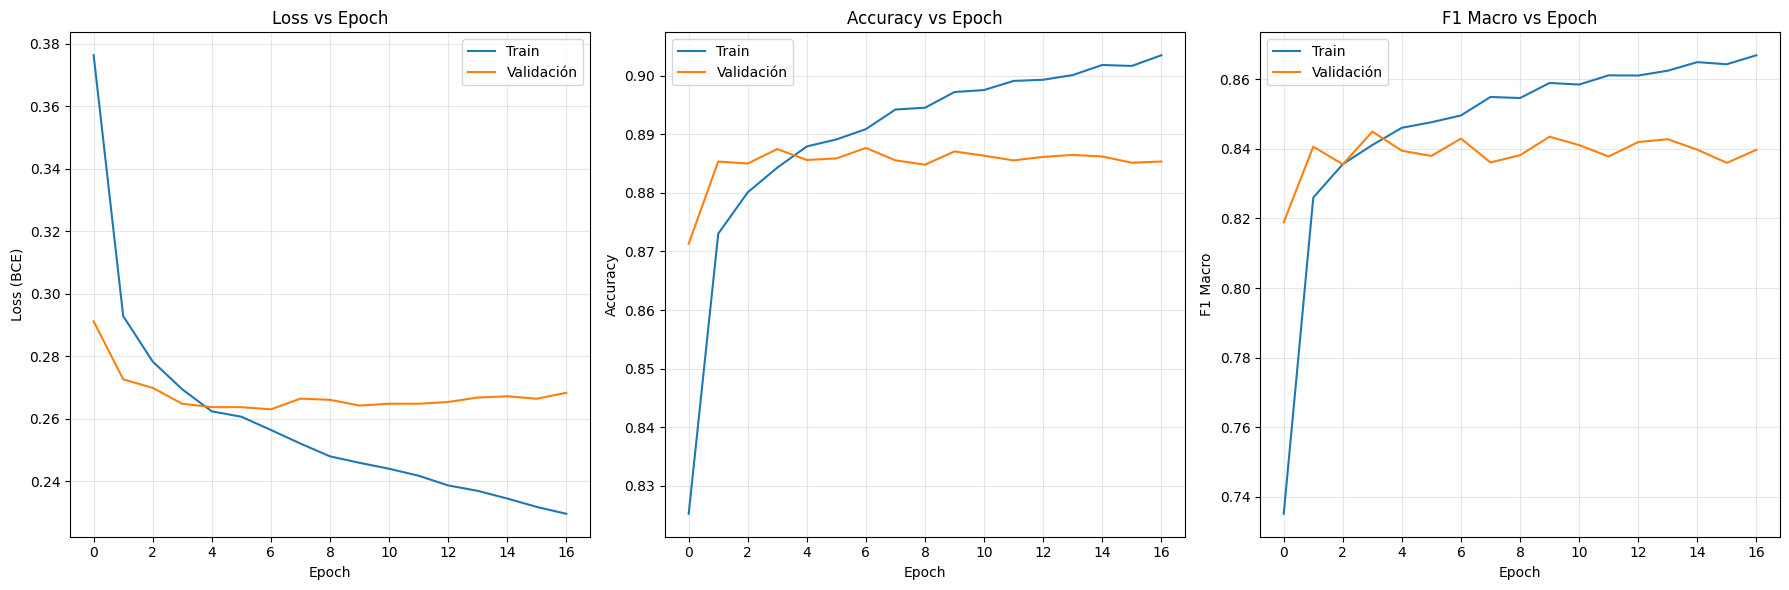

In [ ]:
# Se hace una función para graficar todas las métricas para reutilizar en el siguiente ejercicio.
def plot_metrics(
    train_losses,
    val_losses,
    train_accs,
    val_accs,
    trains_f1s,
    val_f1s
):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    # Loss
    axes[0].plot(train_losses, label='Train')
    axes[0].plot(val_losses, label='Validación')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (BCE)')
    axes[0].set_title('Loss vs Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(train_accs, label='Train')
    axes[1].plot(val_accs, label='Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy vs Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # F1 Macro
    axes[2].plot(train_f1s, label='Train')
    axes[2].plot(val_f1s, label='Validación')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Macro')
    axes[2].set_title('F1 Macro vs Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metrics(
    train_losses,
    val_losses,
    train_accs,
    val_accs,
    train_f1s,
    val_f1s
)

Classification Report: 
              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.93     11360
        >50K       0.80      0.72      0.75      3700

    accuracy                           0.89     15060
   macro avg       0.85      0.83      0.84     15060
weighted avg       0.88      0.89      0.88     15060



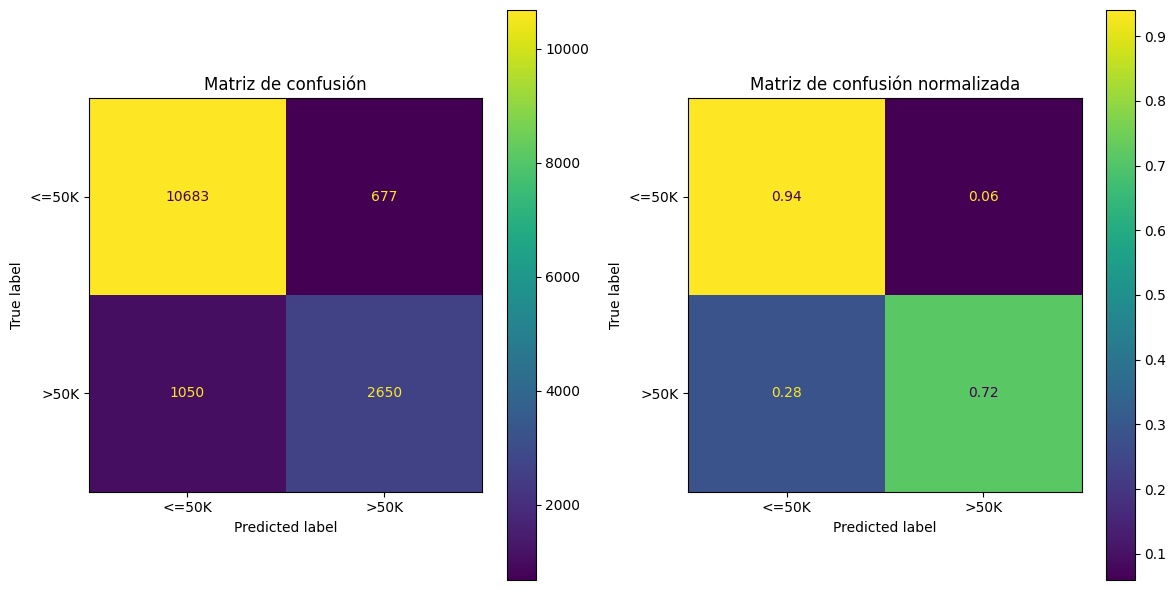

In [59]:
def show_report(model_to_report):
    model_to_report.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in val_loader:
            x_emb = batch["emb"].to(device)
            x_oth = batch["oth"].to(device)
            y = batch["target"]

            outputs = model_to_report(x_emb, x_oth)
            preds = (torch.sigmoid(outputs) >= 0.5).long().cpu()
            all_preds.append(preds)
            all_targets.append(y.long())
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    classes_ = ["<=50K", ">50K"]

    print("Classification Report: ")
    print(classification_report(all_targets, all_preds, target_names=classes_))

    cm = confusion_matrix(all_targets, all_preds)
    cm_norm = confusion_matrix(all_targets, all_preds, normalize='true')

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes_
    )
    disp_norm = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=classes_
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    disp.plot(ax=axes[0])
    axes[0].set_title("Matriz de confusión")

    disp_norm.plot(ax=axes[1])
    axes[1].set_title("Matriz de confusión normalizada")

    plt.tight_layout()
    plt.show()

show_report(model)

-----

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

#### Resolución
Se vuelve a aplicar el codificado pero ahora agregando las columnas que fueron representadas mediante embeddins, al listado de columnas para codificar con One-Hot.

Luego de aplicar esta codificación y antes de las restantes, deberían aparecer $16 + 14 + 80 + 41 = 151$ columnas nuevas, totalizando en $39 - 4 + 151 = 186$. Al aplicar la codificación restante, deberían sumarse 8 columnas al total anterior, es decir quedaría con 194 columnas.

In [76]:
# Limpiar todo, volviendo a leer del csv
df_train = pd.read_csv('data/adult_train.csv')
df_test = pd.read_csv('data/adult_val.csv')

X_train = df_train.drop('income', axis=1)
y_train = (df_train['income'] == '>50K').astype(int)

X_test = df_test.drop('income', axis=1)
y_test = (df_test['income'] == '>50K').astype(int)


In [77]:
# One-Hot Encodings ------------
ohe_cols = [
    "workclass",
    "marital-status",
    "relationship",
    "race",
    "education",
    "occupation",
    "skill-profile",
    "native-country"    
]

X_train_ohe = pd.get_dummies(
    X_train,
    columns=ohe_cols,
    # drop_first=True,
    dtype=int
)
X_val_ohe = pd.get_dummies(
    X_val,
    columns=ohe_cols,
    # drop_first=True,
    dtype=int
)
# Asegurar que tengan las mismas columnas
X_val_ohe = X_val_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)


# Label Encodings -----------
le_sex = LabelEncoder()
X_train_ohe["encoded_sex"] = le_sex.fit_transform(X_train["sex"])
X_val_ohe["encoded_sex"] = le_sex.transform(X_val["sex"])

X_train_ohe.head()

,age,sex,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,encoded_sex
0,39,Male,2174,0,40,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,50,Male,0,0,13,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1
2,38,Male,0,0,40,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,53,Male,0,0,40,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
4,28,Female,0,0,40,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
# Transformaciones numéricas --------

# Escalado para age
sc_age = StandardScaler()
X_train_ohe["scaled_age"] = sc_age.fit_transform(X_train[["age"]])
X_val_ohe["scaled_age"] = sc_age.transform(X_val[["age"]])

# Escalado para hours-per-week
sc_hpw = StandardScaler()
X_train_ohe["scaled_hpw"] = sc_hpw.fit_transform(X_train[["hours-per-week"]])
X_val_ohe["scaled_hpw"] = sc_hpw.transform(X_val[["hours-per-week"]])

# Flag, logaritmo y escalado para capital-gain
X_train_ohe["has_capital_gain"] = (X_train["capital-gain"] > 0).astype(int)
X_val_ohe["has_capital_gain"] = (X_val["capital-gain"] > 0).astype(int)

X_train_ohe["capital_gain_log"] = np.log1p(X_train["capital-gain"])
X_val_ohe["capital_gain_log"] = np.log1p(X_val["capital-gain"])

sc_gain = StandardScaler()
X_train_ohe["scaled_gain"] = sc_gain.fit_transform(
    X_train_ohe[["capital_gain_log"]]
)
X_val_ohe["scaled_gain"] = sc_gain.transform(
    X_val_ohe[["capital_gain_log"]]
)

# Flag, logaritmo y escalado para capital-loss
X_train_ohe["has_capital_loss"] = (X_train["capital-loss"] > 0).astype(int)
X_val_ohe["has_capital_loss"] = (X_val["capital-loss"] > 0).astype(int)

X_train_ohe["capital_loss_log"] = np.log1p(X_train["capital-loss"])
X_val_ohe["capital_loss_log"] = np.log1p(X_val["capital-loss"])

sc_loss = StandardScaler()
X_train_ohe["scaled_loss"] = sc_loss.fit_transform(
    X_train_ohe[["capital_loss_log"]]
)
X_val_ohe["scaled_loss"] = sc_loss.transform(
    X_val_ohe[["capital_loss_log"]]
)

# Debería mostrar 8 columnas más
X_train_ohe.head()

,age,sex,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Yugoslavia,encoded_sex,scaled_age,scaled_hpw,has_capital_gain,capital_gain_log,scaled_gain,has_capital_loss,capital_loss_log,scaled_loss
0,39,Male,2174,0,40,0,0,0,0,0,...,0,1,0.042796,-0.077734,1,7.684784,2.809634,0,0.0,-0.222715
1,50,Male,0,0,13,0,0,0,0,1,...,0,1,0.880288,-2.331531,0,0.000000,-0.301013,0,0.0,-0.222715
2,38,Male,0,0,40,0,0,1,0,0,...,0,1,-0.033340,-0.077734,0,0.000000,-0.301013,0,0.0,-0.222715
3,53,Male,0,0,40,0,0,1,0,0,...,0,1,1.108695,-0.077734,0,0.000000,-0.301013,0,0.0,-0.222715
4,28,Female,0,0,40,0,0,1,0,0,...,0,0,-0.794697,-0.077734,0,0.000000,-0.301013,0,0.0,-0.222715


In [81]:
features = [
    "scaled_age",
    "scaled_hpw",
    "has_capital_gain",
    "scaled_gain",
    "has_capital_loss",
    "scaled_loss",
    "encoded_sex"
] + [col for col in X_train_ohe.columns if any(
    col.startswith(prefix) for prefix in [
        "workclass",
        "marital-status",
        "relationship",
        "race",
        "education",
        "occupation",
        "skill-profile",
        "native-country"
    ]
)]
len(features)

183

In [84]:
# Conversión a tensores
X_train_c = X_train_ohe[features].values.astype(np.float32)
y_train_c = y_train.values.astype(np.float32)

X_val_c = X_val_ohe[features].values.astype(np.float32)
y_val_c = y_val.values.astype(np.float32)

X_train_c_tensor = torch.tensor(X_train_c, dtype=torch.float32)
y_train_c_tensor = torch.tensor(y_train_c, dtype=torch.float32)

X_val_c_tensor = torch.tensor(X_val_c, dtype=torch.float32)
y_val_c_tensor = torch.tensor(y_val_c, dtype=torch.float32)

print(X_train_c_tensor.shape, y_train_c_tensor.shape)
print(X_val_c_tensor.shape, y_val_c_tensor.shape)

torch.Size([30162, 183]) torch.Size([30162])
torch.Size([15060, 183]) torch.Size([15060])


In [86]:
class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "X": self.X,
            "y": self.y
        }

train_dataset = SimpleDataset(X_train_c_tensor, y_train_c_tensor)
val_dataset = SimpleDataset(X_val_c_tensor, y_val_c_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)

In [ ]:
class SimplerClassifier(nn.Module):
    def __init__(self, X):
        super().__init__()


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.